# Realtime Buoys: Woods Hole, Scripps, and Virginia Key

This notebook compares recent realtime standard meteorological observations from selected NDBC stations near Woods Hole/Buzzards Bay, Scripps, and Virginia Key.

The workflow fetches recent hourly observations, maps the station locations, and plots wind speed and water temperature for each station. Because the notebook uses realtime feeds, the exact time range and missing values depend on the current upstream data.


In [1]:
import matplotlib.pyplot as plt
import xndbc
from helpers import plot_stations

## Fetch Realtime Data

Request recent hourly realtime observations for the selected station IDs. The result is an `xarray.Dataset` with a station dimension and time-dependent meteorological variables.


In [2]:
station_ids = ["bzbm3", "46254", "vakf1"]

realtime = xndbc.fetch_data(
    station_ids,
    data_type="realtime",
    sample_rate="H",
)

realtime

Fetching stations: 100%|██████████| 3/3 [00:04<00:00,  1.64s/station]


<xarray.Dataset> Size: 377kB
Dimensions:     (time: 1095, station_id: 3)
Coordinates:
  * time        (time) datetime64[us] 9kB 2026-05-02 ... 2026-06-16T14:00:00
  * station_id  (station_id) <U5 60B '46254' 'bzbm3' 'vakf1'
    latitude    (station_id) float64 24B 32.87 41.52 25.73
    longitude   (station_id) float64 24B -117.3 -70.67 -80.16
Data variables: (12/14)
    WDIR        (station_id, time) float64 26kB nan nan nan ... 219.0 205.0
    WSPD        (station_id, time) float64 26kB nan nan nan ... 4.15 3.95 5.25
    GST         (station_id, time) float64 26kB nan nan nan ... 5.28 4.87 6.45
    WVHT        (station_id, time) float64 26kB 0.7 0.6 0.6 0.55 ... nan nan nan
    DPD         (station_id, time) float64 26kB 6.5 6.5 7.5 6.0 ... nan nan nan
    APD         (station_id, time) float64 26kB 5.2 5.2 5.25 ... nan nan nan
    ...          ...
    ATMP        (station_id, time) float64 26kB nan nan nan ... 29.25 29.55 30.3
    WTMP        (station_id, time) float64 26kB 18.65 18.7 18.65 ... 30.2 30.2
    DEWP        (station_id, time) float64 26kB nan nan nan nan ... nan nan nan
    VIS         (station_id, time) float64 26kB nan nan nan nan ... nan nan nan
    PTDY        (station_id, time) float64 26kB nan nan nan nan ... 0.6 0.8 0.4
    TIDE        (station_id, time) float64 26kB nan nan nan nan ... nan nan nan

## Station Locations

Map the stations included in the realtime request. Labels are added manually so the plotted points can be matched to the station IDs used in the data request.


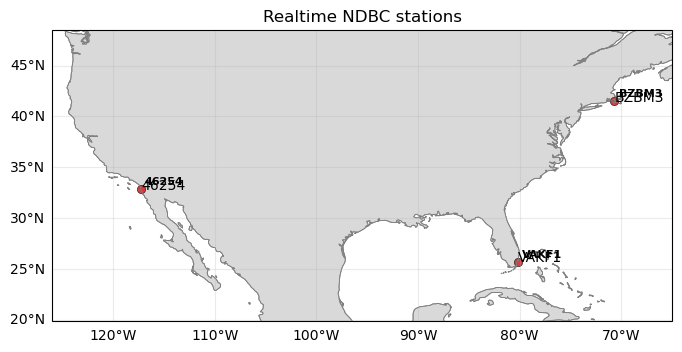

In [3]:
fig, ax = plot_stations(realtime)
for station in realtime.station_id.values:
    row = realtime.sel(station_id=station)
    ax.annotate(str(station).upper(), (row.longitude.item(), row.latitude.item()))
ax.set_extent([-126, -65, 20, 45])
ax.set_title("Realtime NDBC stations")
plt.show()

## Recent Wind Speed

Plot wind speed (`WSPD`) for each station. Stations without available wind-speed values are still included in the legend so missing data are visible rather than silently dropped.


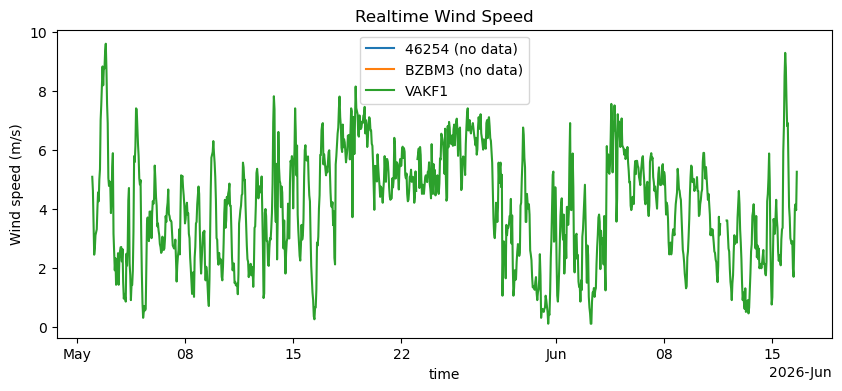

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))
for station in realtime.station_id.values:
    series = realtime.WSPD.sel(station_id=station)
    label = str(station).upper()
    if series.notnull().any():
        series.plot(ax=ax, label=label)
    else:
        ax.plot([], [], label=f"{label} (no data)")
ax.set_ylabel("Wind speed (m/s)")
ax.set_title("Realtime Wind Speed")
ax.legend()
plt.show()

## Recent Water Temperature

Plot water temperature (`WTMP`) for each station. As with wind speed, stations with no available data are shown explicitly in the legend.


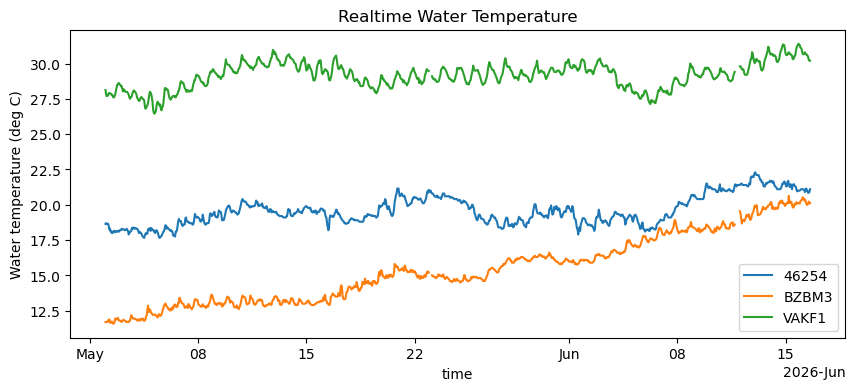

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
for station in realtime.station_id.values:
    series = realtime.WTMP.sel(station_id=station)
    label = str(station).upper()
    if series.notnull().any():
        series.plot(ax=ax, label=label)
    else:
        ax.plot([], [], label=f"{label} (no data)")
ax.set_ylabel("Water temperature (deg C)")
ax.set_title("Realtime Water Temperature")
ax.legend()
plt.show()